# 🎬 Movie Recommendation System using Content-Based Filtering

### 📖 Project Overview

This project builds a Content-Based Movie Recommendation System using Natural Language Processing (NLP) techniques.
The system recommends movies based on:
* Genres
* Keywords
* Cast
* Crew
* Movie Overview
  
By converting movie metadata into vector representations and calculating cosine similarity, the model identifies movies with similar content.

## 🎯 Business Objective

Modern streaming platforms like Netflix, Amazon Prime, and Disney+ use recommendation systems to improve:

User engagement
Watch time
Customer retention
Personalized experience

This project demonstrates how content-based recommendation systems can be built using NLP and machine learning techniques.

## 🌍 Why Recommendation Systems Matter

Recommendation systems are one of the most important applications of machine learning in modern digital platforms.

Companies like Netflix, Amazon Prime, YouTube, and Spotify use recommendation engines to:

- Increase user engagement
- Improve watch time
- Personalize user experience
- Reduce content discovery time
- Increase subscription retention

A good recommendation system directly impacts revenue and customer satisfaction.

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem.porter import PorterStemmer
from sklearn.metrics.pairwise import cosine_similarity

## Dataset Loading

In [2]:
movies = pd.read_csv('data/tmdb_5000_movies.csv')
credits = pd.read_csv('data/tmdb_5000_credits.csv')

In [3]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## 🔍 Initial Observations
Dataset contains both numerical and textual features.
Text-based columns are crucial for recommendation generation.
Some columns contain JSON-like string structures that require preprocessing.

In [5]:
print("Movies Shape:", movies.shape)
print("Credits Shape:", credits.shape)

Movies Shape: (4803, 20)
Credits Shape: (4803, 4)


## 📊 Initial Dataset Analysis

The dataset contains approximately 5000 movies along with metadata such as:

- Genre
- Cast
- Crew
- Keywords
- Plot overview

These textual attributes are highly useful for content-based filtering.

## Merge Section

In [6]:
movies=movies.merge(credits,on="title")

In [7]:
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'crew'],
      dtype='object')

## 📊 Observation

After merging:

- Dataset contains richer metadata.
- Combined information improves recommendation quality.

## 🎯 Feature Selection Strategy

The following features are selected because they strongly influence movie similarity:

| Feature | Reason |
|---|---|
| Overview | Captures movie storyline |
| Genres | Defines movie category |
| Keywords | Identifies themes |
| Cast | Reflects actor preferences |
| Crew | Captures director influence |

These features collectively create a strong semantic representation of movies.

In [8]:
movies=movies[["movie_id","title","overview","genres","keywords","cast","crew"]]

In [9]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [10]:
movies.shape

(4809, 7)

## 🧹 Data Preprocessing
Objectives
* Convert JSON-like strings into lists
* Extract important entities
* Remove missing values
* Standardize textual data

In [11]:
def convert(text):
    L=[]
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

### Objective
This function extracts only the relevant names from JSON-like structures.
 
 Business impact:
 This reduces unnecessary metadata and focuses on meaningful recommendation signals.

In [12]:
def convert1(text):
    L=[]
    count=0
    for i in ast.literal_eval(text):
        if count != 3:
            L.append(i["name"])
            count +=1
        else:
            break
    return L
movies['cast']=movies['cast'].apply(convert1)

### Objective
Only the top 3 cast members are selected because lead actors significantly influence user preference.

In [13]:
def convert2(text):
    L=[]
    for i in ast.literal_eval(text):
        if i["job"] == "Director":
            L.append(i['name'])
            break
    return L
movies['crew']=movies['crew'].apply(convert2)

### Objective
Directors strongly influence movie style and storytelling patterns.

In [14]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

## 🧹 Missing Value Analysis

Some movies contain missing overview data.

Since recommendation quality depends heavily on textual features,
rows with missing important information are removed.

In [15]:
movies.dropna(inplace=True)
movies['overview']=movies['overview'].apply(lambda x: x.split())

In [16]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


## 🏷 Feature Engineering — Creating Tags
Multiple textual features are combined into a single "tags" column.

This creates a unified textual representation of each movie.

The tags include:

* Story overview
* Genres
* Keywords
* Cast
* Crew

This combined representation becomes the foundation for vectorization.

In [17]:
movies['tags']=(movies['overview'] +
    movies['genres'] +
    movies['keywords'] +
    movies['cast'] +
    movies['crew']
)

In [18]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],"[John, Carter, is, a, war-weary,, former, mili..."


In [19]:
new_df=movies[['movie_id','title','tags']].copy()
new_df['tags']=new_df['tags'].apply(lambda x: " ".join(x))
new_df['tags']=new_df["tags"].apply(lambda x: x.lower())
new_df=new_df.head(2000)
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


## Text Vectorization
The textual tags are converted into numerical vectors using CountVectorizer.             

Why?

Machine learning models cannot directly understand text.
Vectorization transforms textual information into mathematical representations

In [20]:
cv=CountVectorizer(max_features=5000,stop_words='english')
vectors=cv.fit_transform(new_df['tags']).toarray()

In [21]:
vectors.shape

(2000, 5000)

In [22]:
print(cv.get_feature_names_out())

['000' '007' '10' ... 'zucker' 'zwick' 'åkerman']


## ✂ Text Normalization using Stemming
Stemming reduces words to their root forms.

Examples:

* "Loved" → "Love"
* "Acting" → "Act"

Benefits:
* Reduces vocabulary size
* Improves similarity detection
* Enhances recommendation quality

In [23]:
ps=PorterStemmer()
def stem(text):
    y=[]
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)
new_df['tags']=new_df['tags'].apply(stem)
print(new_df['tags'].head())

0    in the 22nd century, a parapleg marin is dispa...
1    captain barbossa, long believ to be dead, ha c...
2    a cryptic messag from bond’ past send him on a...
3    follow the death of district attorney harvey d...
4    john carter is a war-weary, former militari ca...
Name: tags, dtype: object


## 📐 Cosine Similarity Calculation
Cosine similarity measures the angle between movie vectors.

Higher cosine similarity means:

* Similar genres
* Similar story themes
* Similar cast/director patterns

In [24]:
similarity=cosine_similarity(vectors)
similarity.shape

(2000, 2000)

## 📌 Observation

The similarity matrix stores pairwise similarity scores between all movies.

This enables instant recommendation retrieval.

## 🎯 Movie Recommendation Engine
The recommendation engine:

1. Finds the selected movie
2. Retrieves similarity scores
3. Sorts movies by similarity
4. Returns top recommended movies

In [25]:
def recommend(movie):
    movie_index=new_df[new_df["title"].str.lower().str.contains(movie.lower())].index[0]
    distances=similarity[movie_index]
    movies_list=sorted(
        list(enumerate(distances)),
        reverse=True,
    key=lambda x: x[1])[1:6]
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

## Recommendation Testing

In [26]:
recommend("dark")

The Dark Knight
Batman Begins
Batman
Batman
Batman Returns


## 📌 Recommendation Quality Observation

The model successfully identifies movies with:

- Similar themes
- Similar genres
- Similar cinematic style

Example:

Batman movies recommend other superhero/action movies.

## 📊 Genre Distribution

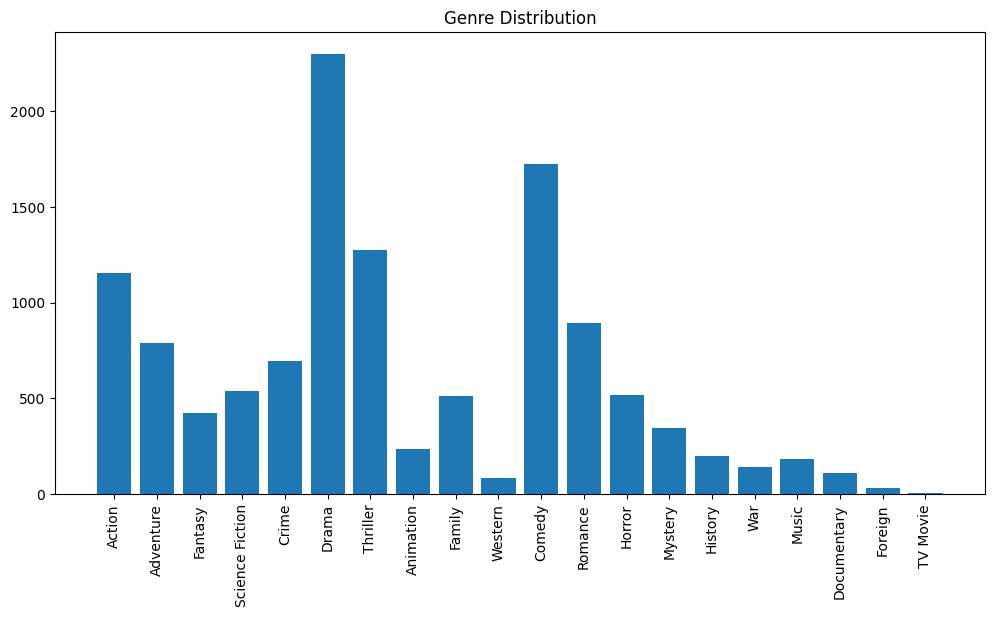

In [27]:
all_genres = []

for genre_list in movies['genres']:
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)

plt.figure(figsize=(12,6))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.xticks(rotation=90)
plt.title("Genre Distribution")
plt.show()

## Observation
Action, Drama, Thriller, and Comedy appear most frequently. This aligns with trends seen in OTT platforms.

## Saving Model Artifacts
The processed dataset and similarity matrix are saved for deployment in:

* Streamlit apps
* Flask APIs
* Web applications

In [28]:
new_df.to_csv('movies.csv')
pickle.dump(similarity,open("similarity.pkl","wb"))

# 💼 Business Insights

## 1. Popular Genres Dominate User Attention
Action, Drama, Thriller, and Comedy appear most frequently.
This aligns with trends seen in OTT platforms.

---

## 2. Recommendation Systems Increase User Retention
Users are more likely to remain active when personalized recommendations reduce search effort.

---

## 3. Metadata Quality Directly Impacts Recommendation Accuracy
Rich movie metadata improves semantic understanding and recommendation relevance.

---

## 4. Actor and Director Influence User Preference
Many users search for movies based on favorite actors or directors.
Including cast and crew significantly improves recommendation quality.

# ⚠ Limitations

This recommendation system has several limitations:

- Does not use user ratings
- Cannot learn evolving user preferences
- Recommendations depend heavily on metadata quality
- Semantic understanding is limited compared to deep learning models
- No collaborative filtering implemented

# 🚀 Future Improvements

Possible future enhancements include:

- Hybrid recommendation system
- Collaborative filtering
- Deep learning embeddings
- Transformer-based NLP models
- Real-time recommendation API
- Streamlit deployment
- Movie poster integration
- User personalization

# ✅ Conclusion

This project successfully demonstrates how Natural Language Processing and cosine similarity can be used to build a content-based movie recommendation system.

The system processes movie metadata, converts textual information into vector representations, and identifies semantically similar movies.

This project highlights:

- NLP preprocessing
- Feature engineering
- Vectorization
- Similarity computation
- Recommendation system design

The notebook also demonstrates how machine learning can improve user experience in entertainment platforms.